In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.odr import RealData, Model, ODR
import sys
sys.path.append("../../..")
from baseLabs import *
import copy

In [2]:
def f(beta,x):
    return beta[0]/x+beta[1]

freq = 50

# **Circuito B**

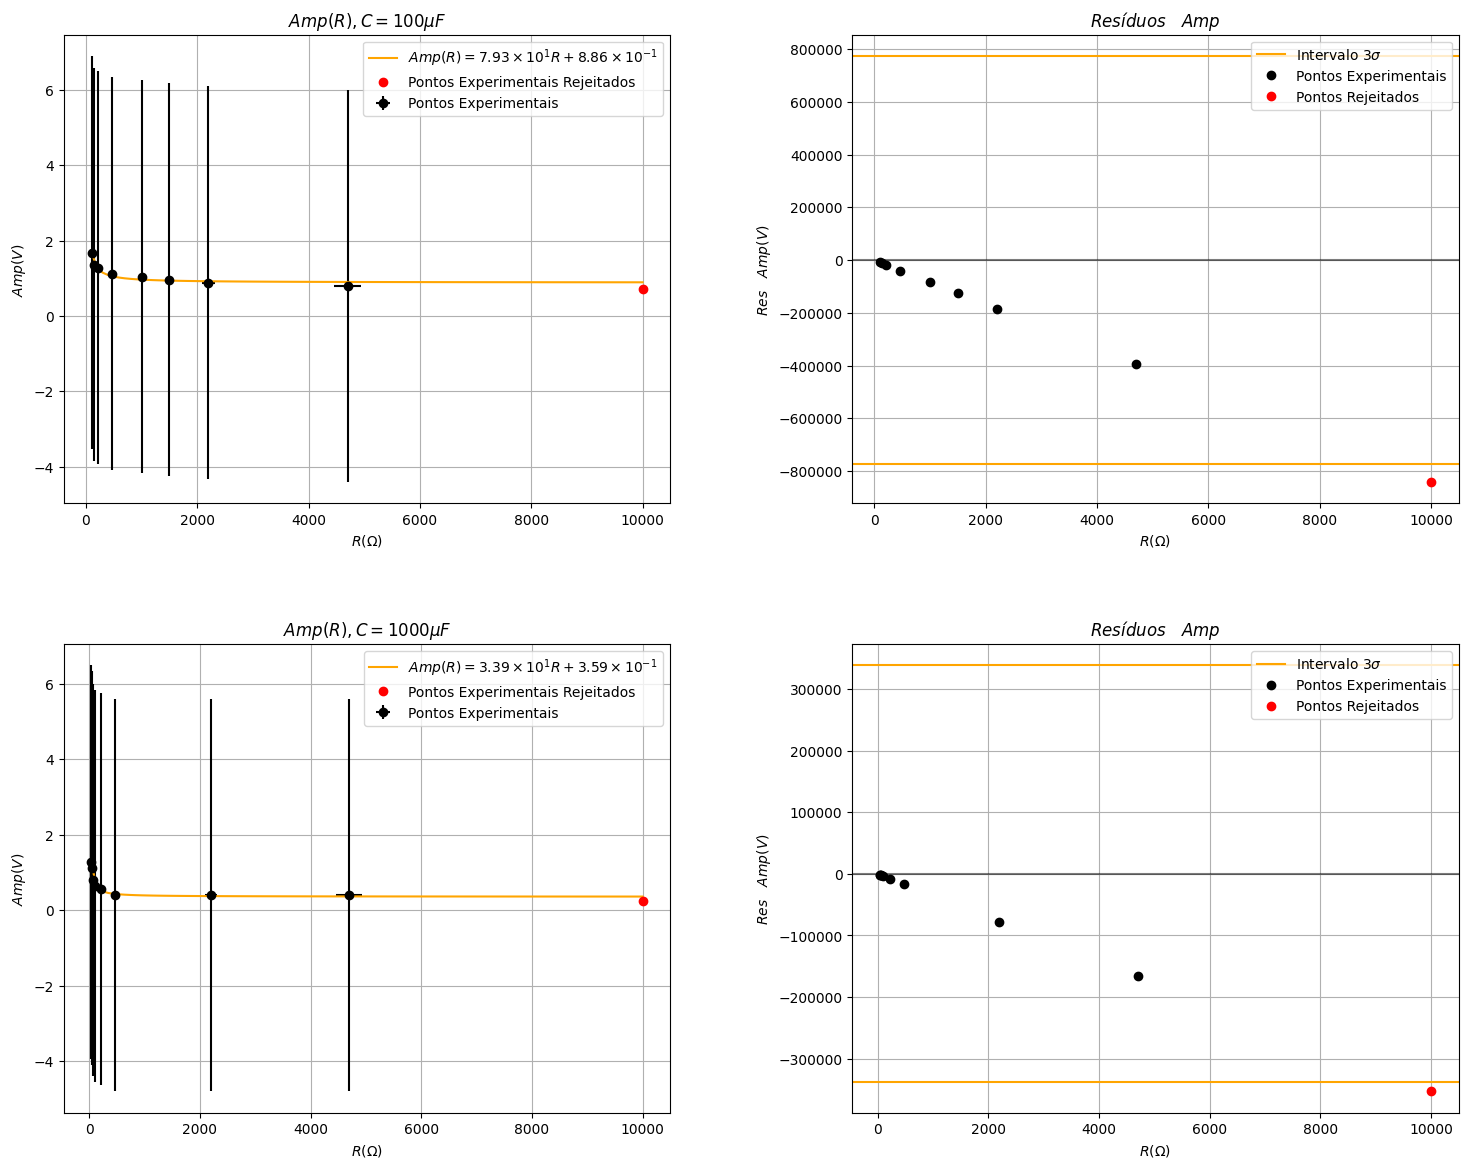

In [3]:
R100B, uR100B, amp100B, uAmp100B, peak100B, uPeak100B, iAC100B, uIAC100B, iDC100B, uIDC100B, R1000B, uR1000B, amp1000B, uAmp1000B, peak1000B, uPeak1000B, iAC1000B, uIAC1000B, iDC1000B, uIDC1000B = getData("dados3.txt",skip=0)

mask = np.isnan(amp1000B)
R1000B, uR1000B, amp1000B, uAmp1000B, peak1000B, uPeak1000B, iAC1000B, uIAC1000B, iDC1000B, uIDC1000B = R1000B[~mask], uR1000B[~mask], amp1000B[~mask], uAmp1000B[~mask], peak1000B[~mask], uPeak1000B[~mask], iAC1000B[~mask], uIAC1000B[~mask], iDC1000B[~mask], uIDC1000B[~mask]

R100B, amp100B, uR100B, uAmp100B, peak100B, uPeak100B, iAC100B, uIAC100B, iDC100B, uIDC100B = R100B[1:-5], amp100B[1:-5], uR100B[1:-5], uAmp100B[1:-5], peak100B[1:-5], uPeak100B[1:-5], iAC100B[1:-5], uIAC100B[1:-5], iDC100B[1:-5], uIDC100B[1:-5]

adjusts = plotColumnReg([R100B,R1000B],[amp100B,amp1000B],[uR100B,uR1000B],[uAmp100B,uAmp1000B],["Amp(R), C=100 μF","Amp(R), C=1000 μF"],["R(\Omega)","R(\Omega)"],["Amp(V)","Amp(V)"],f,tol=3)

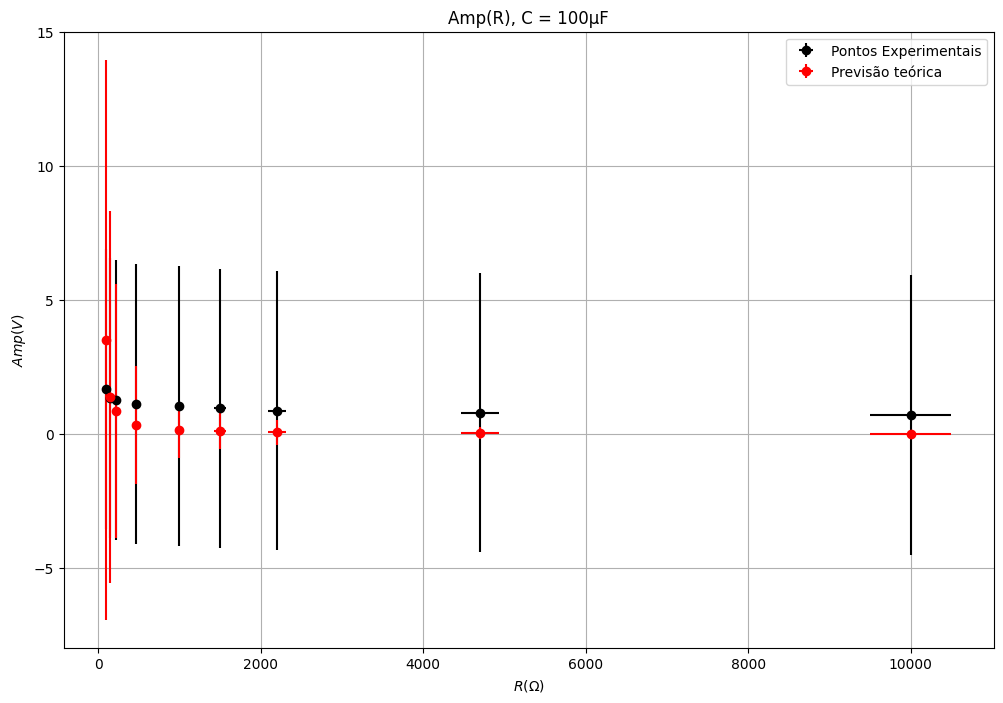

array([<scipy.odr._odrpack.Output object at 0x000002A4E2D99350>,
      dtype=object)

In [4]:
ampT100B = peak100B/(freq*R100B*100e-6)
uAmpT100B = np.sqrt((uPeak100B/(freq*R100B*100e-6))**2+(peak100B/(freq*R100B**2*100e-6)*uR100B)**2)

plotMultipleReg([R100B,R100B],[amp100B,ampT100B],[uR100B,uR100B],[uAmp100B,uAmpT100B],"Amp(R), C = 100μF","R(\Omega)","Amp(V)",["black","red"],["Pontos Experimentais", "Previsão teórica"],False)

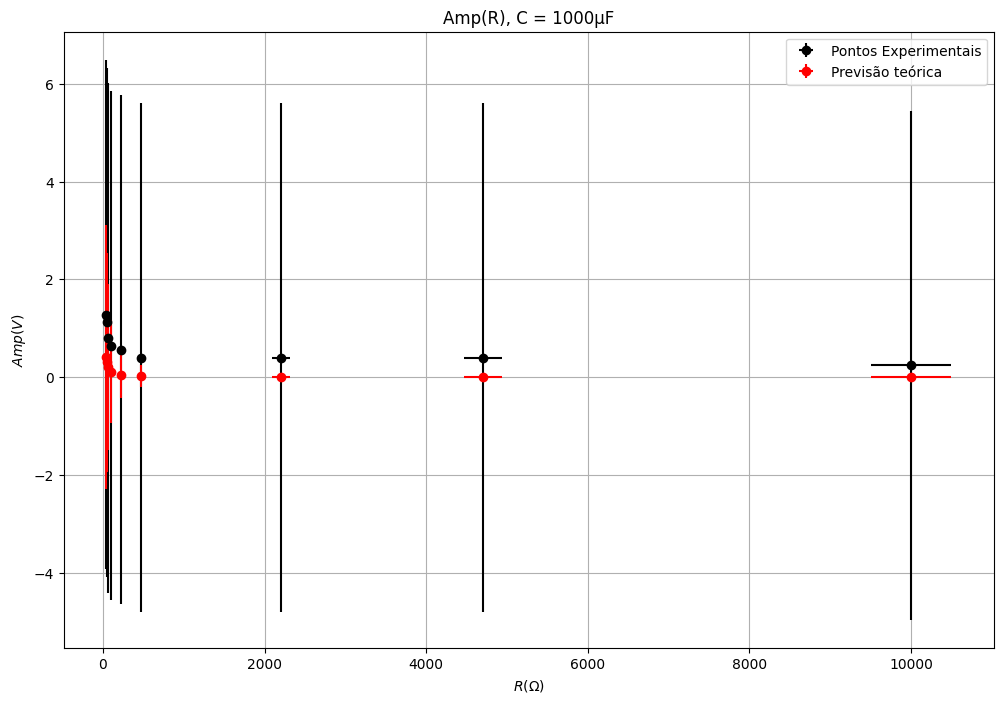

array([<scipy.odr._odrpack.Output object at 0x000002A4E2D9CF30>,
      dtype=object)

In [5]:
ampT1000B = peak1000B/(freq*R1000B*1000e-6)
uAmpT1000 = np.sqrt((uPeak1000B/(freq*R1000B*1000e-6))**2+(peak1000B/(freq*R1000B**2*1000e-6)*R1000B)**2)

plotMultipleReg([R1000B,R1000B],[amp1000B,ampT1000B],[uR1000B,uR1000B],[uAmp1000B,uAmpT1000],"Amp(R), C = 1000μF","R(\Omega)","Amp(V)",["black","red"],["Pontos Experimentais", "Previsão teórica"],False)

# **Circuito A**

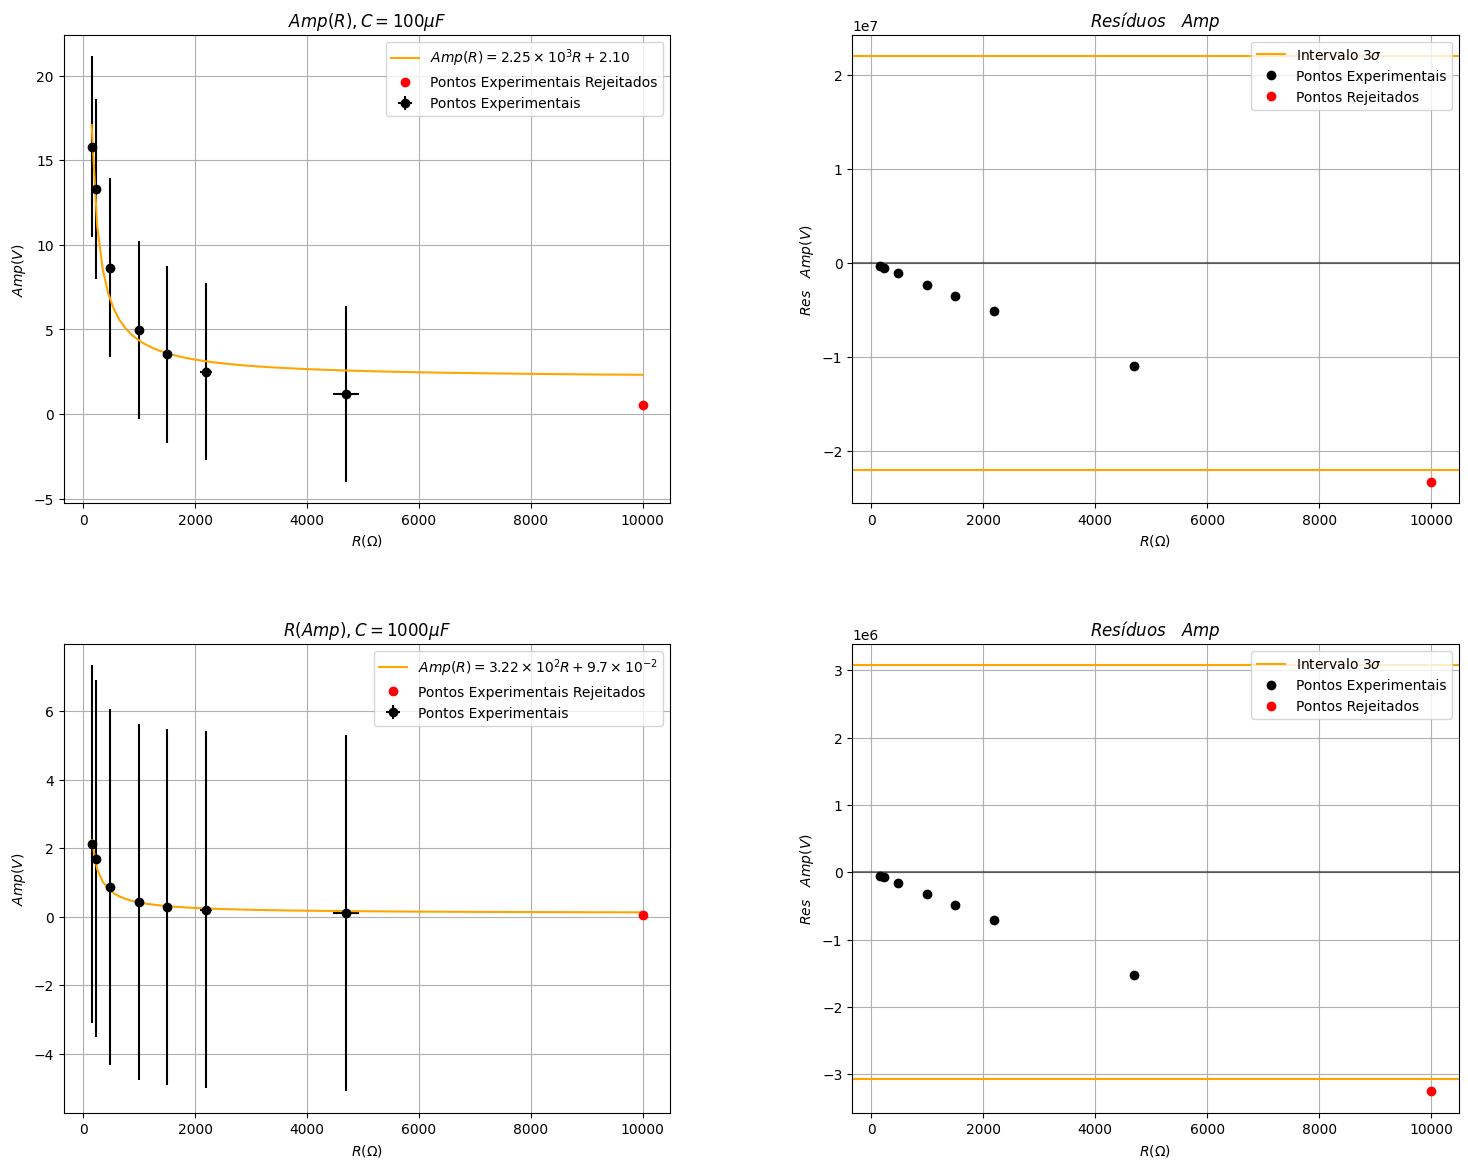

In [6]:
R100, uR100, amp100, uAmp100, peak100, uPeak100, R1000, uR1000, amp1000, uAmp1000, peak1000, uPeak1000 = getData("circAA.txt",skip=1)

R100, uR100, amp100, uAmp100, peak100, uPeak100 = np.delete(R100,[1,2]), np.delete(uR100,[1,2]), np.delete(amp100,[1,2]), np.delete(uAmp100,[1,2]), np.delete(peak100,[1,2]), np.delete(uPeak100,[1,2])
R1000, uR1000, amp1000, uAmp1000, peak1000, uPeak1000 = np.delete(R1000,[1,2]), np.delete(uR1000,[1,2]), np.delete(amp1000,[1,2]), np.delete(uAmp1000,[1,2]), np.delete(peak1000,[1,2]), np.delete(uPeak1000,[1,2])

adjusts = plotColumnReg([R100,R1000],[amp100,amp1000],[uR100,uR1000],[uAmp100,uAmp1000],["Amp(R), C=100 μF","R(Amp), C=1000 μF"],["R(\Omega)","R(\Omega)"],["Amp(V)","Amp(V)"],f,tol=3)

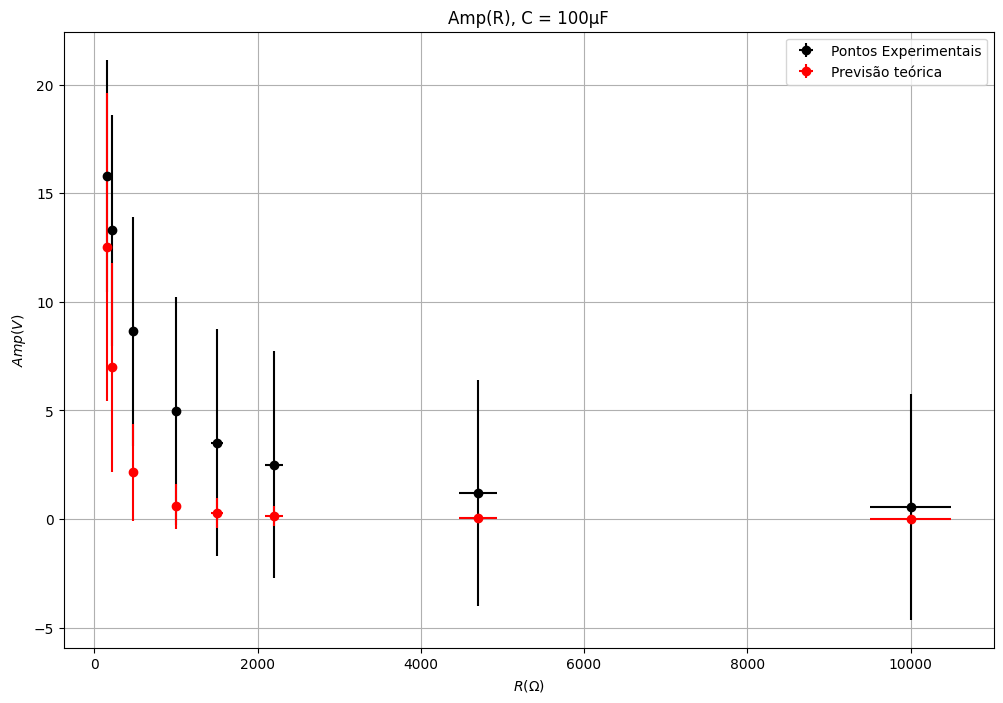

array([<scipy.odr._odrpack.Output object at 0x000002A4E3656210>,
      dtype=object)

In [7]:
ampT100 = peak100/(freq*R100*100e-6)
uAmpT100 = np.sqrt((uPeak100/(freq*R100*100e-6))**2+(peak100/(freq*R100**2*100e-6)*uR100)**2)

plotMultipleReg([R100,R100],[amp100,ampT100],[uR100,uR100],[uAmp100,uAmpT100],"Amp(R), C = 100μF","R(\Omega)","Amp(V)",["black","red"],["Pontos Experimentais", "Previsão teórica"],False)

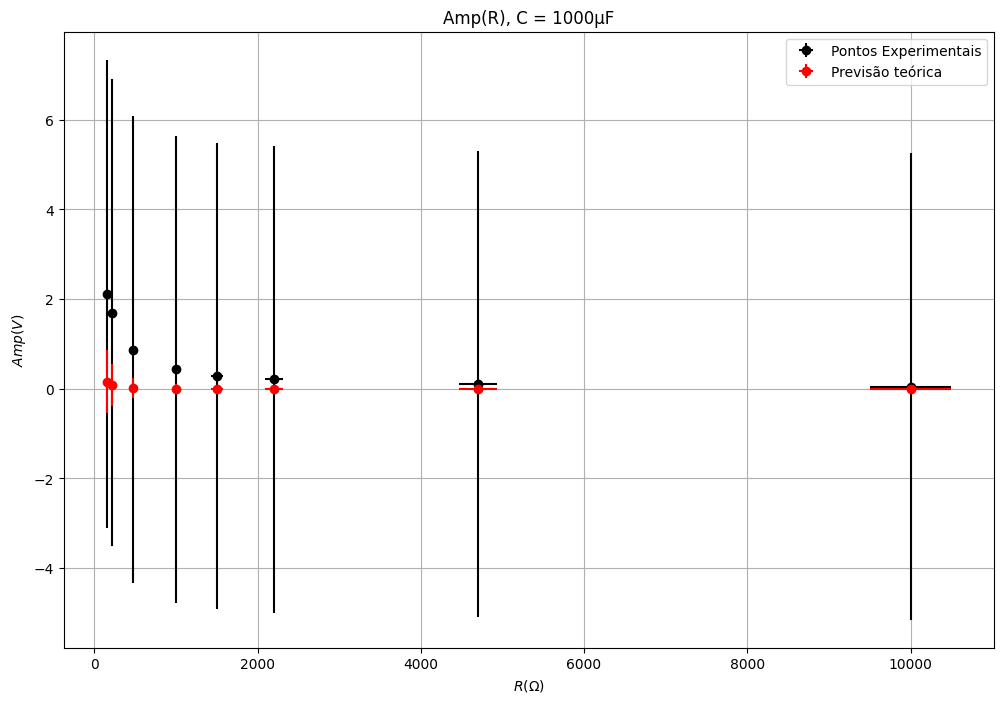

array([<scipy.odr._odrpack.Output object at 0x000002A4E35F35C0>,
      dtype=object)

In [8]:
ampT1000 = peak1000/(freq*R1000*1000e-6)
uAmpT1000 = np.sqrt((uPeak1000/(freq*R1000*1000e-6))**2+(peak1000/(freq*R1000**2*1000e-6)*uR1000)**2)

plotMultipleReg([R100,R100],[amp1000,ampT1000],[uR1000,uR1000],[uAmp1000,uAmpT1000],"Amp(R), C = 1000μF","R(\Omega)","Amp(V)",["black","red"],["Pontos Experimentais", "Previsão teórica"],False)

[  220.  1000. 10000.  4700.   150.  2200.  1500.   470.]
[10000.  4700.  2200.  1500.  1000.   470.   220.   150.   100.]


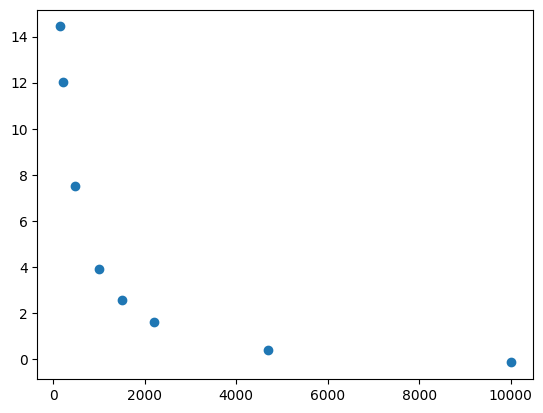

In [9]:
print(R100)
print(R100B)

order100 = np.argsort(R100)
R100New = R100[order100]
amp100New = amp100[order100]

order100B = np.argsort(R100B)
R100BNew = R100B[order100B]
amp100BNew = amp100B[order100B]

dif = amp100New - amp100BNew[1:]

plt.scatter(R100New,dif)

# **Comparações**

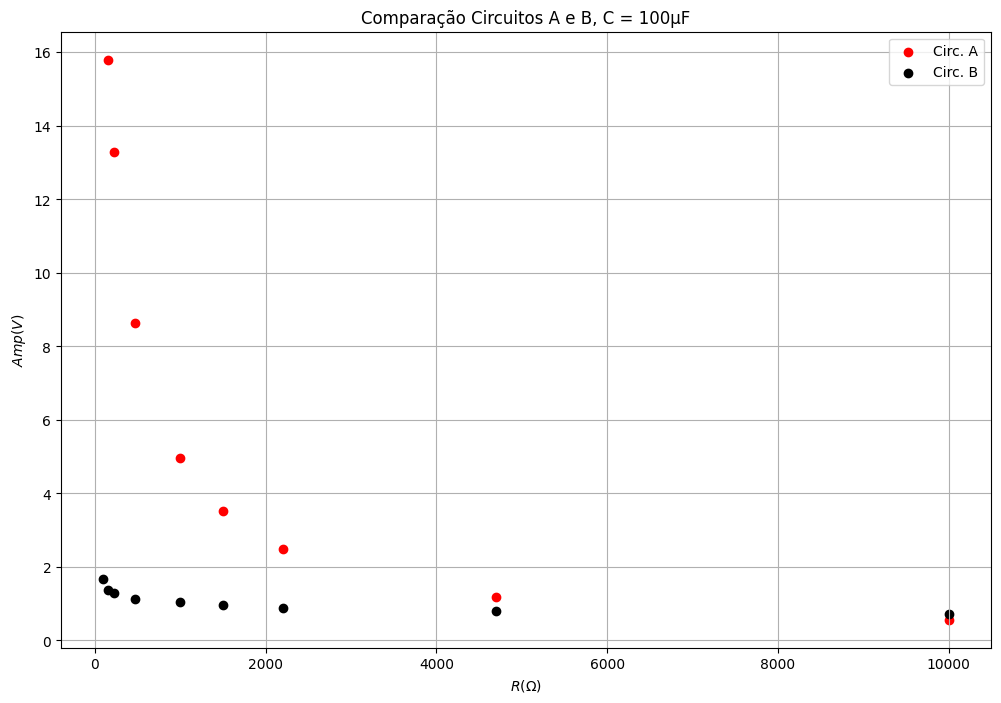

array([<scipy.odr._odrpack.Output object at 0x000002A4E3654D70>,
      dtype=object)

In [10]:
plotMultipleReg([R100,R100B],[amp100,amp100B],[uR100,uR100B],[uAmp100,uAmp100B],"Comparação Circuitos A e B, C = 100μF","R(\Omega)","Amp (V)",["red","black"],["Circ. A", "Circ. B"],errorbars=False)

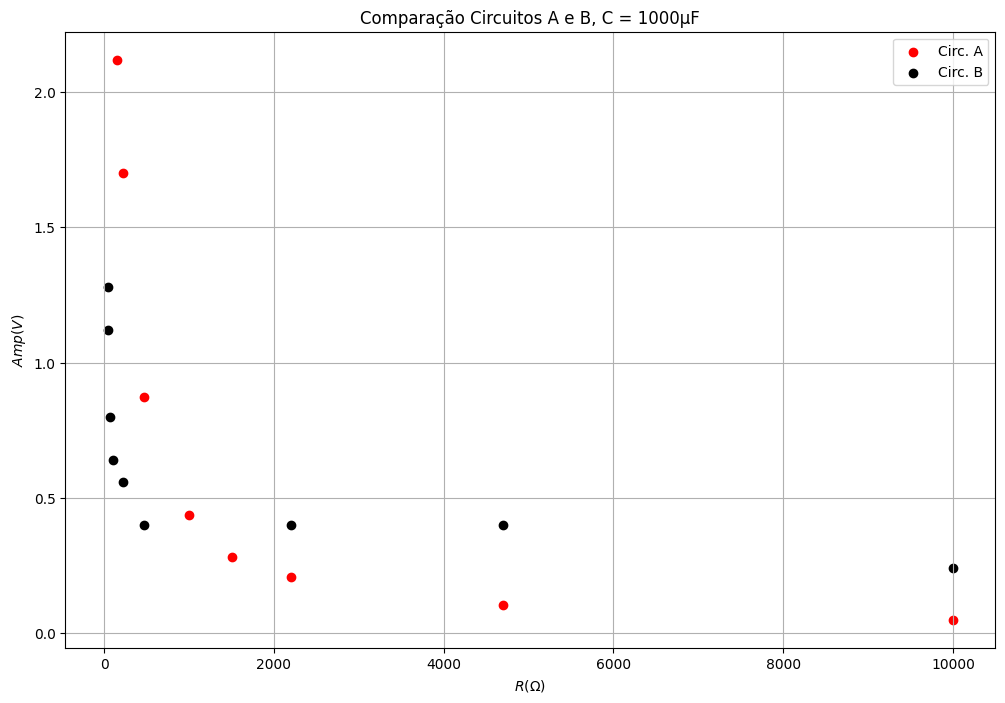

array([<scipy.odr._odrpack.Output object at 0x000002A4E35F3980>,
      dtype=object)

In [11]:
plotMultipleReg([R1000,R1000B],[amp1000,amp1000B],[uR1000,uR1000B],[uAmp1000,uAmp1000B],"Comparação Circuitos A e B, C = 1000μF","R(\Omega)","Amp (V)",["red","black"],["Circ. A", "Circ. B"],errorbars=False)

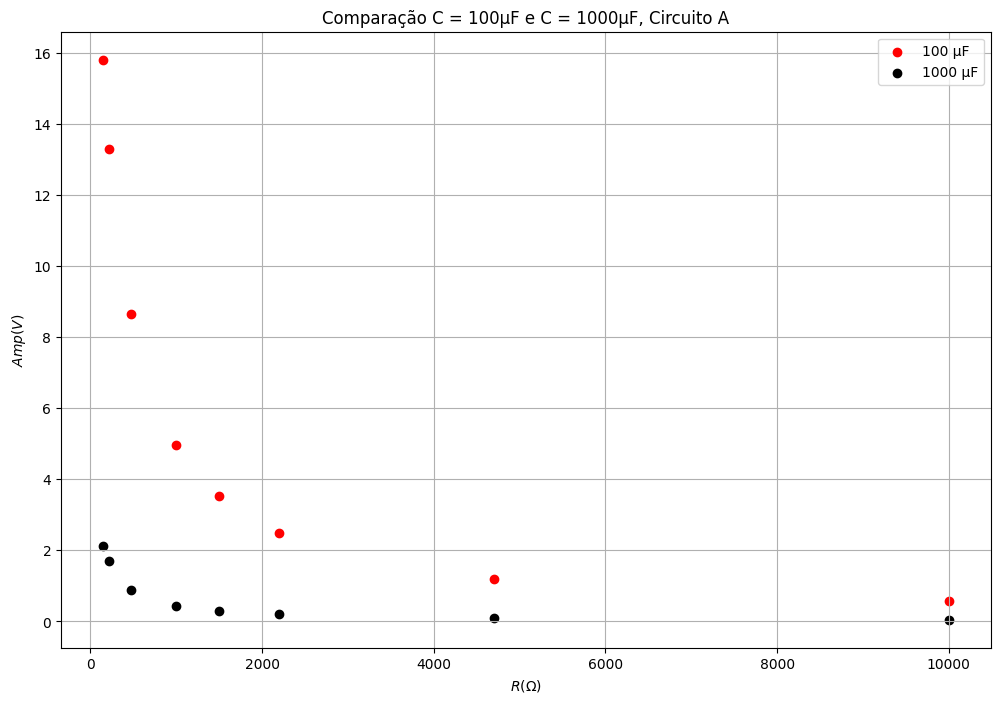

array([<scipy.odr._odrpack.Output object at 0x000002A4E35F32F0>,
      dtype=object)

In [12]:
plotMultipleReg([R100,R1000],[amp100,amp1000],[uR100,uR1000],[uAmp100,uAmp1000],"Comparação C = 100μF e C = 1000μF, Circuito A","R(\Omega)","Amp (V)",["red","black"],["100 μF", "1000 μF"],errorbars=False)

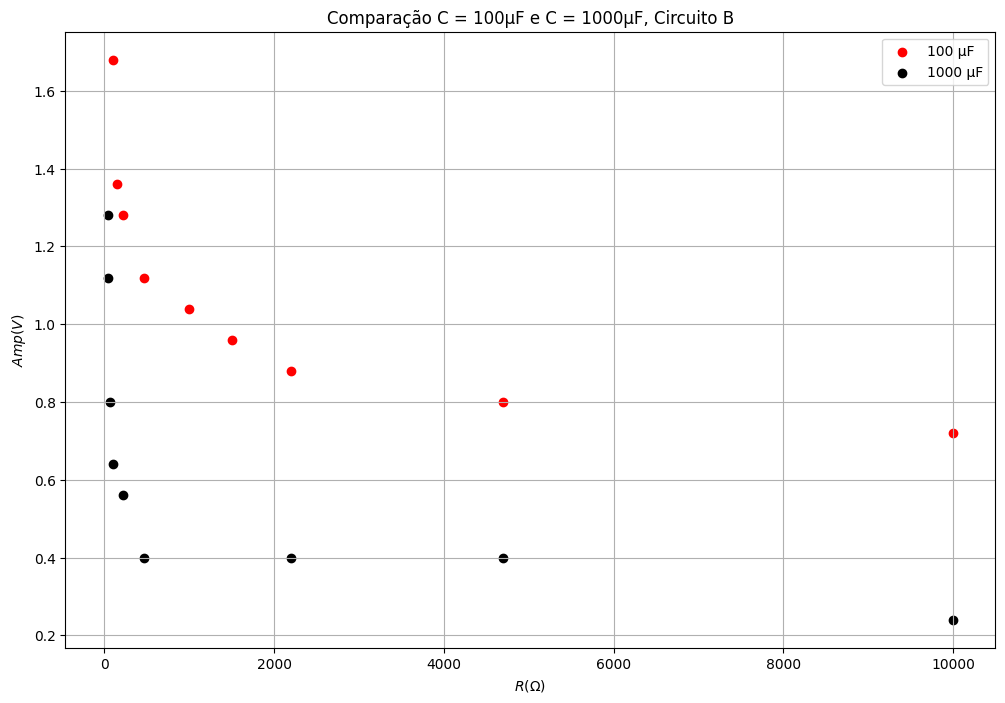

array([<scipy.odr._odrpack.Output object at 0x000002A4E3657200>,
      dtype=object)

In [13]:
plotMultipleReg([R100B,R1000B],[amp100B,amp1000B],[uR100B,uR1000B],[uAmp100B,uAmp1000B],"Comparação C = 100μF e C = 1000μF, Circuito B","R(\Omega)","Amp (V)",["red","black"],["100 μF", "1000 μF"],errorbars=False)